# Saguaro bud count data 2016 - 2026

## Load Data

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import scikit_posthocs as sp
from sklearn.linear_model import LinearRegression

In [2]:
# load bud count csv
df = pd.read_csv('Saguaro Bud Counts - Sheet1.csv')
df.head()

,Image,Year,Bud Count
0,15,2016,0
1,18,2016,9
2,19,2016,11
3,20,2016,51
4,21,2016,3


## Graph Data

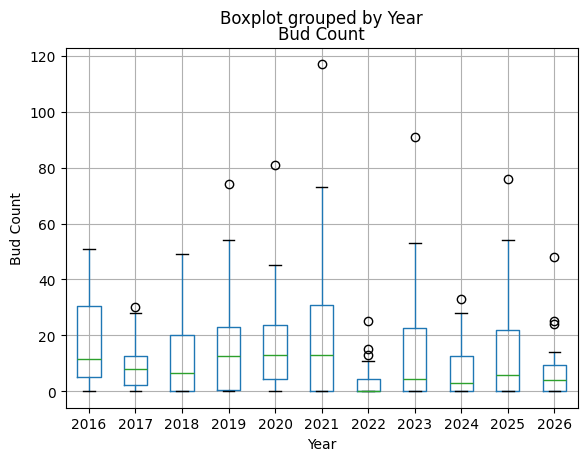

In [3]:
# box plot by year
df.boxplot(column='Bud Count', by='Year')

plt.xlabel("Year")
plt.ylabel("Bud Count")
plt.show()

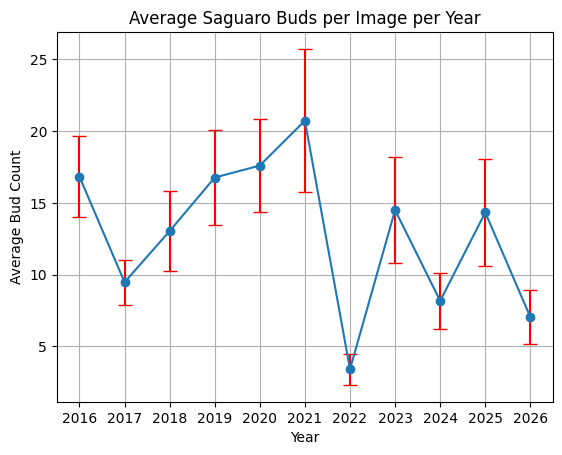

In [4]:
# line plot for mean each year with standard errors
yearly_buds_mean = df.groupby('Year')['Bud Count'].mean()
yearly_buds_se = df.groupby('Year')['Bud Count'].sem()

plt.errorbar(yearly_buds_mean.index, yearly_buds_mean.values, yerr=yearly_buds_se.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Bud Count")
plt.title("Average Saguaro Buds per Image per Year")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

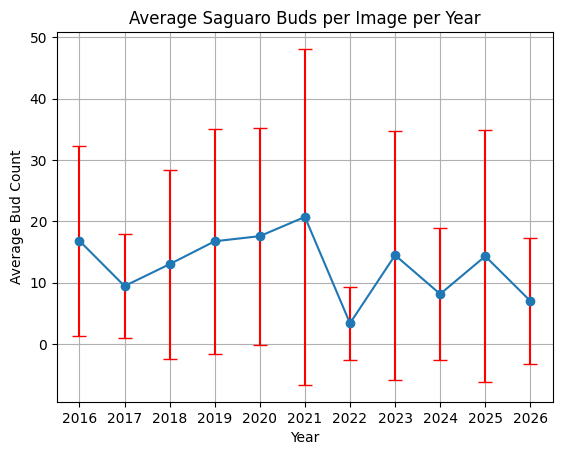

In [5]:
# line plot for mean each year with standard deviation
yearly_buds_std = df.groupby('Year')['Bud Count'].std()

plt.errorbar(yearly_buds_mean.index, yearly_buds_mean.values, yerr=yearly_buds_std.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Bud Count")
plt.title("Average Saguaro Buds per Image per Year")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

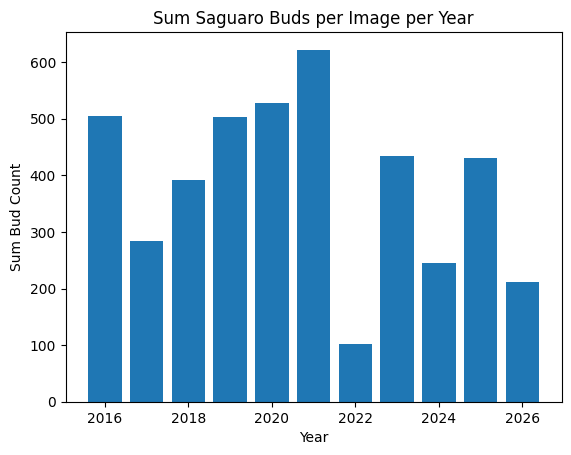

In [6]:
# bar plot for sums each year
yearly_buds_sum = df.groupby('Year')['Bud Count'].sum()

plt.bar(yearly_buds_sum.index, yearly_buds_sum.values)

plt.xlabel("Year")
plt.ylabel("Sum Bud Count")
plt.title("Sum Saguaro Buds per Image per Year")
plt.show()

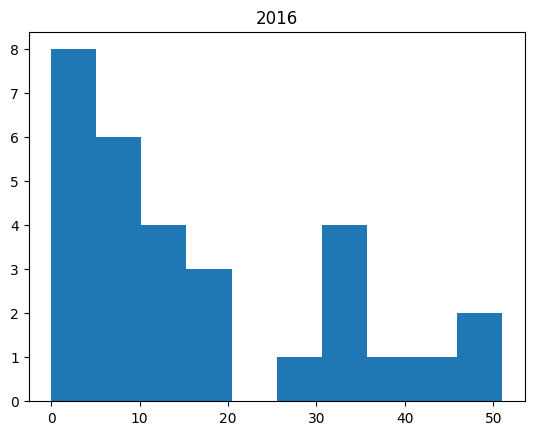

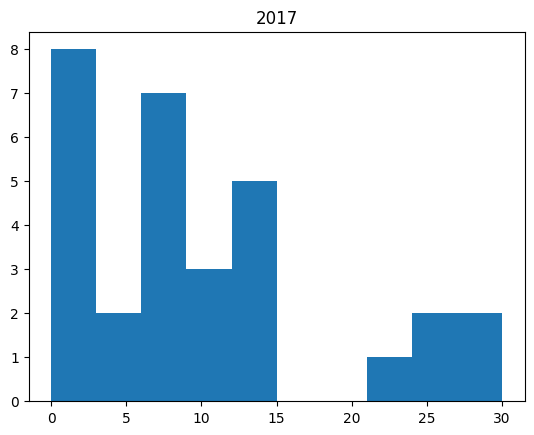

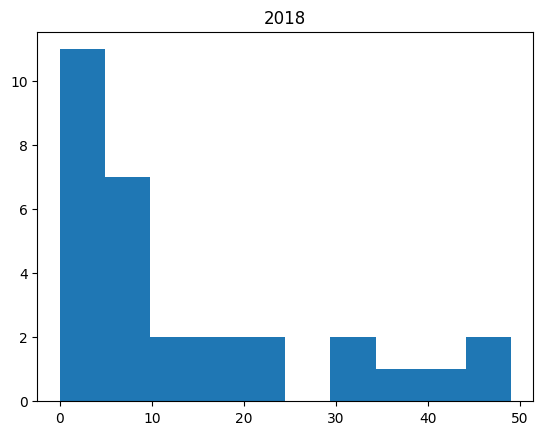

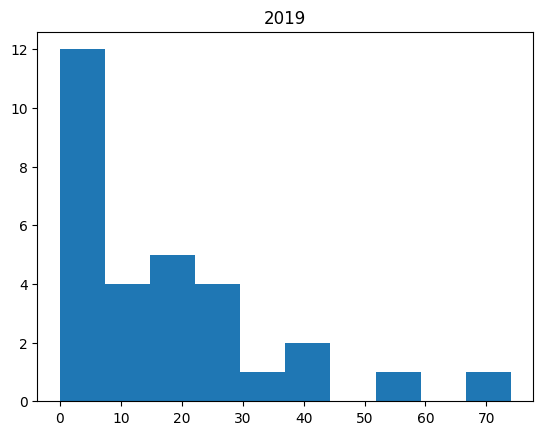

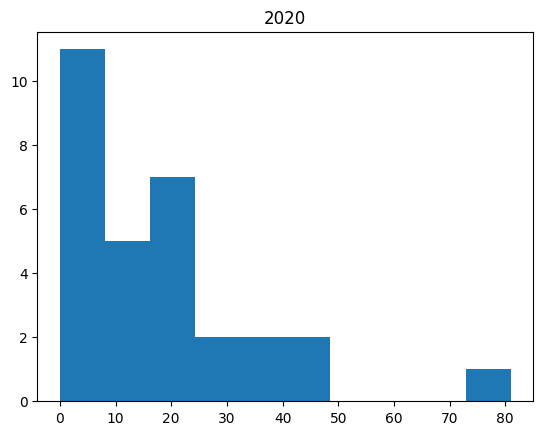

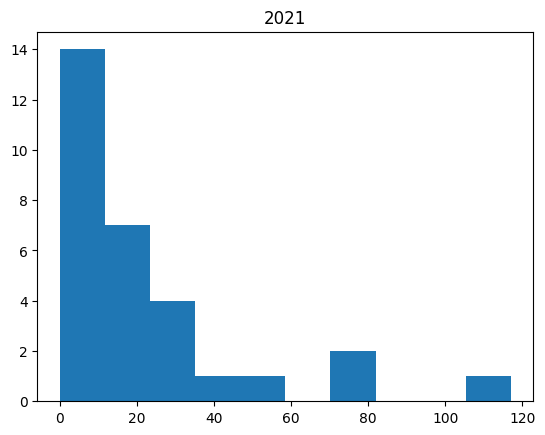

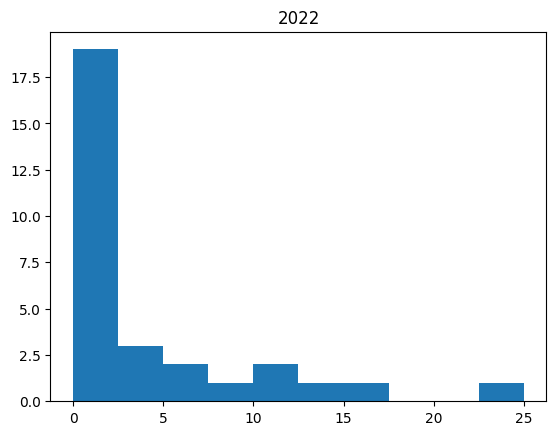

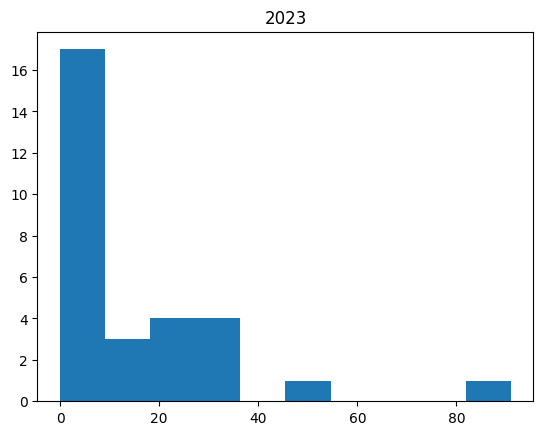

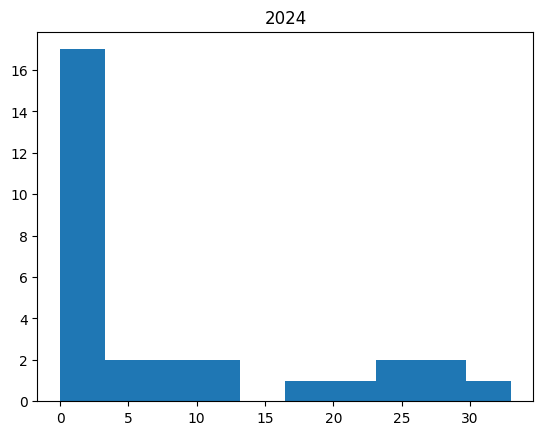

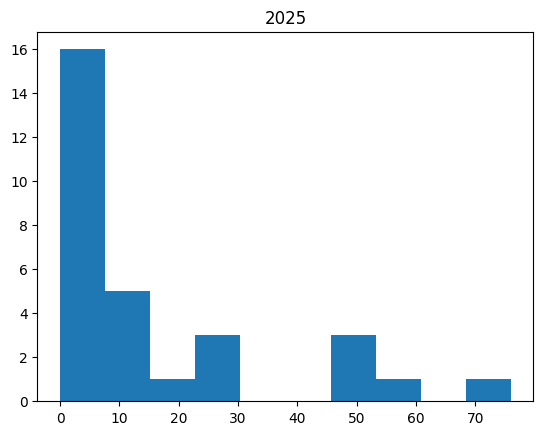

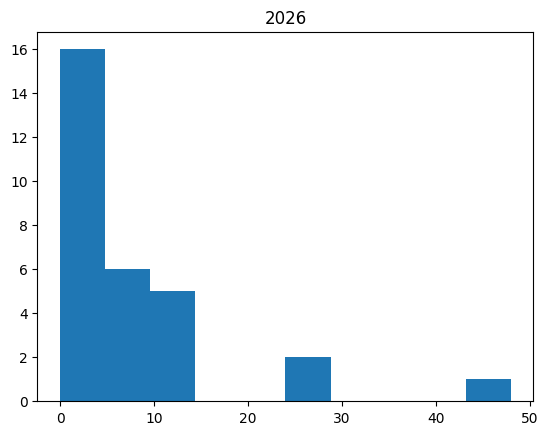

In [7]:
# make a histogram of each year 
for i in df.Year.unique():
    plt.hist(df[df['Year'] == i]['Bud Count'])
    plt.title(i)
    plt.show()

## Statistical Analysis

In [8]:
# check if anova test is valid
# check normality
model = LinearRegression()
model.fit(df[['Year']], df[['Bud Count']])

predictions = model.predict(df[['Year']])
residuals = df[['Bud Count']] - predictions

stat, p = stats.shapiro(residuals)
print("Shapiro-Wilk p-value:", p)

# check homogeneity of variances
buds_2016 = df.loc[df['Year'] == 2016, 'Bud Count']
buds_2017 = df.loc[df['Year'] == 2017, 'Bud Count']
buds_2018 = df.loc[df['Year'] == 2018, 'Bud Count']
buds_2019 = df.loc[df['Year'] == 2019, 'Bud Count']
buds_2020 = df.loc[df['Year'] == 2020, 'Bud Count']
buds_2021 = df.loc[df['Year'] == 2021, 'Bud Count']
buds_2022 = df.loc[df['Year'] == 2022, 'Bud Count']
buds_2023 = df.loc[df['Year'] == 2023, 'Bud Count']
buds_2024 = df.loc[df['Year'] == 2024, 'Bud Count']
buds_2025 = df.loc[df['Year'] == 2025, 'Bud Count']
buds_2026 = df.loc[df['Year'] == 2026, 'Bud Count']
data = [buds_2016, buds_2017, buds_2018, buds_2019, buds_2020, buds_2021, buds_2022, buds_2023, buds_2024, buds_2025, buds_2026]

stat1, p1 = stats.levene(buds_2016, buds_2017, buds_2018, buds_2019, buds_2020, buds_2021, buds_2022, buds_2023, buds_2024, buds_2025, buds_2026)
print("Levene's p-value:", p1)

Shapiro-Wilk p-value: 3.0590918639177354e-21
Levene's p-value: 0.0004972388890877143


The Shapiro-Wilk p-value being less than 0.05 shows that the data is not normally distributed. The Levene's p-value is also less than 0.05, showing that the data does not have homogeneity of variances. Since the data is neither normally distributed nor has homogeneity of variences, we must continue with a non parametric test. 

In [9]:
# since anova is not valid do kruskal wallis
h_stat, p2 = stats.kruskal(buds_2016, buds_2017, buds_2018, buds_2019, buds_2020, buds_2021, buds_2022, buds_2023, buds_2024, buds_2025, buds_2026)
print("H-statistic:", h_stat)
print("P-Value:", p2)

H-statistic: 31.43912535314998
P-Value: 0.0004963270782984553


The p-value being less than 0.05 shows that there is a significant difference between the means of at least some of the amount of buds in each image each year. Now a non parametric pairwise comparison test will be done on the data to see which years are different.

In [10]:
# do dunns test
dunn_results = sp.posthoc_dunn(data, p_adjust='bonferroni')
dunn_results.columns = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
dunn_results.index =  ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
dunn_results

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
2016,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.001108,1.000000,0.485416,1.00000,0.363864
2017,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.200536,1.000000,1.000000,1.00000,1.000000
2018,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.264685,1.000000,1.000000,1.00000,1.000000
2019,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.018962,1.000000,1.000000,1.00000,1.000000
2020,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.002301,1.000000,0.780305,1.00000,0.593587
2021,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.023670,1.000000,1.000000,1.00000,1.000000
2022,0.001108,0.200536,0.264685,0.018962,0.002301,0.02367,1.000000,0.354168,1.000000,0.90784,1.000000
2023,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.354168,1.000000,1.000000,1.00000,1.000000
2024,0.485416,1.000000,1.000000,1.000000,0.780305,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000
2025,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.907840,1.000000,1.000000,1.00000,1.000000


Significant differences: 2016 and 2022, 2019 and 2022, 2020 and 2022, 2021 and 2022. It seems that most of the years are not significantly different than the others except for 2022. 

## Remove outliers

In [11]:
# get outliers
clean_data = []

for year in df['Year'].unique():
    year_data = df[df['Year'] == year]

    Q1 = year_data['Bud Count'].quantile(0.25)
    Q3 = year_data['Bud Count'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    clean_year = year_data[
        (year_data['Bud Count'] >= lower) &
        (year_data['Bud Count'] <= upper)
    ]

    clean_data.append(clean_year)

df_no_outliers = pd.concat(clean_data)

In [12]:
df_no_outliers.info()

<class 'pandas.DataFrame'>
Index: 317 entries, 0 to 329
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Image      317 non-null    int64
 1   Year       317 non-null    int64
 2   Bud Count  317 non-null    int64
dtypes: int64(3)
memory usage: 9.9 KB


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Image      330 non-null    int64
 1   Year       330 non-null    int64
 2   Bud Count  330 non-null    int64
dtypes: int64(3)
memory usage: 7.9 KB


13 outliers removed

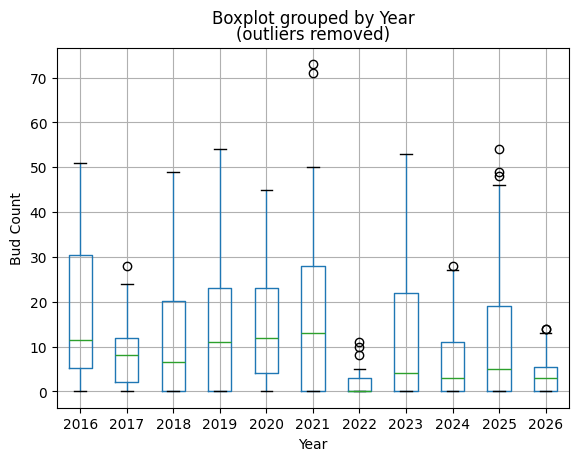

In [14]:
# box plot by year
df_no_outliers.boxplot(column='Bud Count', by='Year')

plt.xlabel("Year")
plt.ylabel("Bud Count")
plt.title("(outliers removed)")
plt.show()

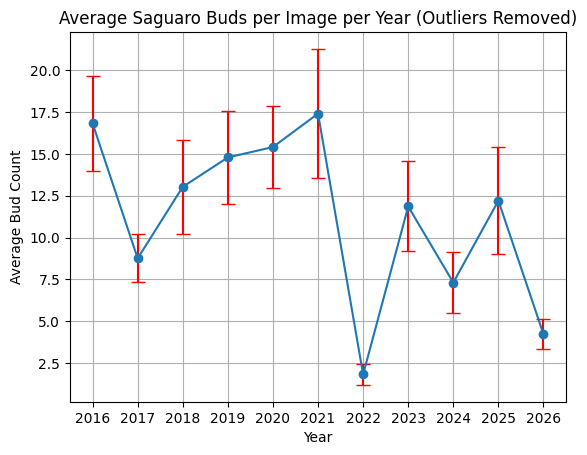

In [15]:
# line plot for mean each year with standard errors
yearly_buds_mean1 = df_no_outliers.groupby('Year')['Bud Count'].mean()
yearly_buds_se1 = df_no_outliers.groupby('Year')['Bud Count'].sem()

plt.errorbar(yearly_buds_mean1.index, yearly_buds_mean1.values, yerr=yearly_buds_se1.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Bud Count")
plt.title("Average Saguaro Buds per Image per Year (Outliers Removed)")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

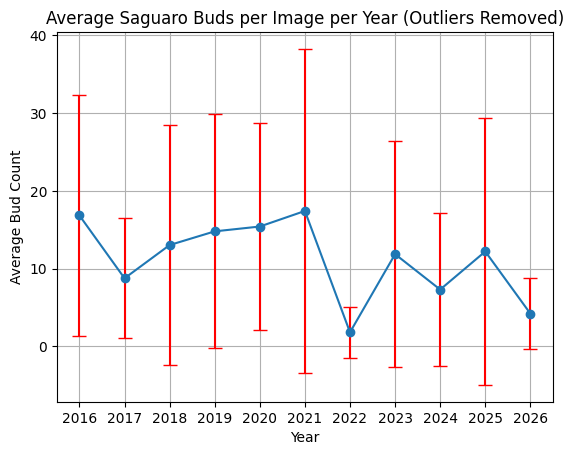

In [16]:
# line plot for mean each year with standard deviation
yearly_buds_std1 = df_no_outliers.groupby('Year')['Bud Count'].std()

plt.errorbar(yearly_buds_mean1.index, yearly_buds_mean1.values, yerr=yearly_buds_std1.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Bud Count")
plt.title("Average Saguaro Buds per Image per Year (Outliers Removed)")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

In [19]:
# check if anova test is valid
# check normality
model1 = LinearRegression()
model1.fit(df_no_outliers[['Year']], df_no_outliers[['Bud Count']])

predictions1 = model1.predict(df_no_outliers[['Year']])
residuals1 = df_no_outliers[['Bud Count']] - predictions1

stat2, p3 = stats.shapiro(residuals1)
print("Shapiro-Wilk p-value:", p3)

# check homogeneity of variances
obuds_2016 = df_no_outliers.loc[df['Year'] == 2016, 'Bud Count']
obuds_2017 = df_no_outliers.loc[df['Year'] == 2017, 'Bud Count']
obuds_2018 = df_no_outliers.loc[df['Year'] == 2018, 'Bud Count']
obuds_2019 = df_no_outliers.loc[df['Year'] == 2019, 'Bud Count']
obuds_2020 = df_no_outliers.loc[df['Year'] == 2020, 'Bud Count']
obuds_2021 = df_no_outliers.loc[df['Year'] == 2021, 'Bud Count']
obuds_2022 = df_no_outliers.loc[df['Year'] == 2022, 'Bud Count']
obuds_2023 = df_no_outliers.loc[df['Year'] == 2023, 'Bud Count']
obuds_2024 = df_no_outliers.loc[df['Year'] == 2024, 'Bud Count']
obuds_2025 = df_no_outliers.loc[df['Year'] == 2025, 'Bud Count']
obuds_2026 = df_no_outliers.loc[df['Year'] == 2026, 'Bud Count']
data1 = [obuds_2016, obuds_2017, obuds_2018, obuds_2019, obuds_2020, obuds_2021, obuds_2022, obuds_2023, obuds_2024, obuds_2025, obuds_2026]

stat3, p4 = stats.levene(obuds_2016, obuds_2017, obuds_2018, obuds_2019, obuds_2020, obuds_2021, obuds_2022, obuds_2023, obuds_2024, obuds_2025, obuds_2026)
print("Levene's p-value:", p4)

Shapiro-Wilk p-value: 4.212862181372787e-18
Levene's p-value: 3.3693334755564397e-06


The Shapiro-Wilk p-value is less than 0.05 meaning that the data is not normally distributed. The Levene's p-value is also less than 0.05 meaning that the data does not have homogeneity of variences. Since the data is neither normally distributed nor has homogeneity of variences, a non parametric test must be done.  

In [20]:
# do kruskal test on all years without outliers
h_stat1, p_val1 = stats.kruskal(obuds_2016, obuds_2017, obuds_2018, obuds_2019, obuds_2020, obuds_2021, obuds_2022, obuds_2023, obuds_2024, obuds_2025, obuds_2026)

print("h-statistic:", h_stat1)
print("p-value:", p_val1)

h-statistic: 39.885583604182344
p-value: 1.7749104836219654e-05


Since the p-value is less than 0.05, there is a significant difference between at least some of the means of buds each year. A non parametric pairwise comparison test will be done to see the differences between each year

In [21]:
# dunn test on data without outliers
dunn_results1 = sp.posthoc_dunn(data1, p_adjust='bonferroni')
dunn_results1.columns = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
dunn_results1.index =  ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
dunn_results1

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
2016,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000056,1.000000,0.224422,1.000000,0.044679
2017,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.037761,1.000000,1.000000,1.000000,1.000000
2018,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.031198,1.000000,1.000000,1.000000,1.000000
2019,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.003763,1.000000,1.000000,1.000000,0.777796
2020,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000346,1.000000,0.667015,1.000000,0.154334
2021,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.005367,1.000000,1.000000,1.000000,0.982368
2022,0.000056,0.037761,0.031198,0.003763,0.000346,0.005367,1.000000,0.108495,1.000000,0.315709,1.000000
2023,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.108495,1.000000,1.000000,1.000000,1.000000
2024,0.224422,1.000000,1.000000,1.000000,0.667015,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2025,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.315709,1.000000,1.000000,1.000000,1.000000


Significantly different: 2022 and 2016, 2016 and 2026, 2017 and 2022, 2018 and 2022, 2019 and 2022, 2020 and 2022, 2021 and 2022. This shows that, with outliers removed, there are a few more significant differences between each year but not many. 2022 becomes more significantly different from each year and 2016 and 2022 are also now significantly different. 